In [161]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as ss
from scipy.stats import norm, variation, kurtosis, skew


In [126]:
df = pd.read_excel('BD_Extraccion.xlsx',sheet_name='datos', header=1)   # utilizamos la ubicacion fisica de archivo en la pc
df.head(3)

,FECHA,TURNO,ZONA,TIPO_LABOR,NIVEL,CUERPO,LABOR,VOLQUETES,PLAN_SEMANAL,PLAN_DIARIO,ACARREO_DIARIO
0,2020-01-01,A,Zona Alta,Tajos,1910.0,OB6A,T-841B,NaN,2500.0,NaN,NaN
1,2020-01-01,A,Zona Alta,Tajos,1880.0,OB6A,T-731B,6.0,1000.0,2500.0,1575.0
2,2020-01-01,A,Zona Alta,Tajos,1880.0,OB6A,T-761E,5.0,2000.0,2500.0,2690.0


ANALISIS DATA POR DIA, utilizamos el dataframe df1

In [125]:
#Generamos Dataframe df1, acarreo Diario
df1 = df.groupby(['FECHA'])[('PLAN_DIARIO','ACARREO_DIARIO')].sum().reset_index(['FECHA'])

df1.head(3)

,FECHA,PLAN_DIARIO,ACARREO_DIARIO
0,2020-01-01,18000.0,15889.0
1,2020-01-02,18200.0,19411.0
2,2020-01-03,20700.0,18752.0


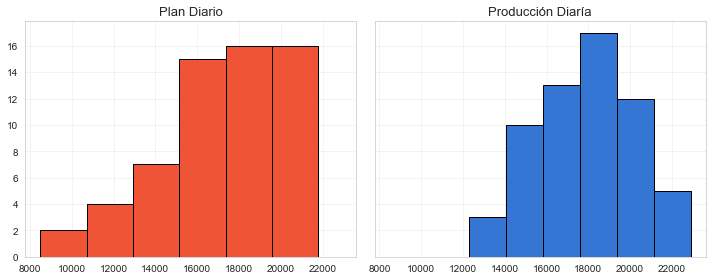

In [115]:
# Histogramas
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10,4), sharey=True, sharex=True)
#fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2)


ax0.hist(x = df1['PLAN_DIARIO'], bins = 6, histtype='bar', edgecolor='#000000', color='#EE5435')
ax0.set_title('Plan Diario', fontsize=13)
ax0.grid(linestyle=':', linewidth='0.5', color='grey', alpha=0.5)

ax1.hist(x = df1['ACARREO_DIARIO'], bins = 6, histtype='bar', edgecolor='#000000',color='#3575D3')
ax1.grid(linestyle=':', linewidth='0.5', color='grey', alpha=0.5)
ax1.set_title('Producción Diaría',fontsize=13)


fig.tight_layout()
plt.show()

In [127]:

#Media :Es el promedio de todos los valores en los datos
#Mediana : Es el valor que se encuentra en el centro del conjunto de datos

df1.describe()

,PLAN_DIARIO,ACARREO_DIARIO
count,60.000000,60.000000
mean,17383.333333,17812.650000
std,3010.218004,2409.943996
min,8500.000000,12271.000000
25%,16000.000000,16350.750000
50%,17900.000000,17960.000000
75%,19825.000000,19445.000000
max,21800.000000,22890.000000


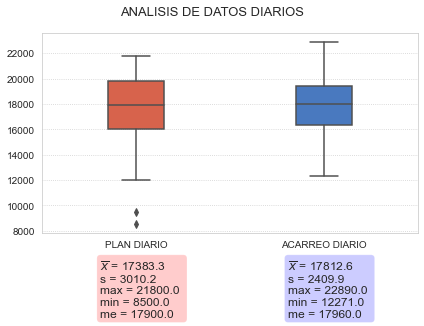

In [128]:
# Proposed themes: darkgrid, whitegrid, dark, white, and ticks
#sns.set(style='whitegrid')
sns.set_style("whitegrid", {'grid.linestyle': ':' } )
fig, axes = plt.subplots(1, 1, figsize=(6,5))
fig.suptitle('ANALISIS DE DATOS DIARIOS', fontsize=13)
my_colors = ["#EE5435", "#3575D3"]
sns.set_palette(my_colors)
g = sns.boxplot(data=df1, width=0.3)  

xvalues = ["PLAN DIARIO","ACARREO DIARIO"]
plt.xticks(np.arange(2), xvalues)
### Provide mean and standard deviation for each product ###


# Text p1
mean = round(df1['PLAN_DIARIO'].mean(),1)
sd = round(df1['PLAN_DIARIO'].std(),1)
ma = round(df1['PLAN_DIARIO'].max(),1)
mi = round(df1['PLAN_DIARIO'].min(),1)
me = round(df1['PLAN_DIARIO'].median(),1)

textstr = "$\overline {x}$" + f" = {mean} \ns = {sd} \nmax = {ma} \nmin = {mi} \nme = {me}"
props = dict(boxstyle='round', facecolor='r', alpha=0.2)
g.text(-0.19, 1200, textstr, fontsize=12, bbox=props)

# Text p2
mean = round(df1['ACARREO_DIARIO'].mean(),1)
sd = round(df1['ACARREO_DIARIO'].std(),1)
ma = round(df1['ACARREO_DIARIO'].max(),1)
mi = round(df1['ACARREO_DIARIO'].min(),1)
me = round(df1['ACARREO_DIARIO'].median(),1)

textstr = "$\overline {x}$" + f" = {mean} \ns = {sd} \nmax = {ma} \nmin = {mi} \nme = {me} "
props = dict(boxstyle='round', facecolor='b', alpha=0.2)
g.text(.81, 1200, textstr, fontsize=12, bbox=props)

plt.tight_layout()
plt.show()


Analisis datos diarios, graficos Boxplot: generamos dataframe df2df2

In [122]:
df2 = df.groupby(['FECHA','ZONA'])[('PLAN_DIARIO','ACARREO_DIARIO')].sum().reset_index(['FECHA','ZONA'])
df2.head(3)

,FECHA,ZONA,PLAN_DIARIO,ACARREO_DIARIO
0,2020-01-01,Zona Alta,10000.0,8477.0
1,2020-01-01,Zona Baja,8000.0,7412.0
2,2020-01-02,Zona Alta,7100.0,6918.0


Text(0.5, 1.0, 'Acarreo Diario')

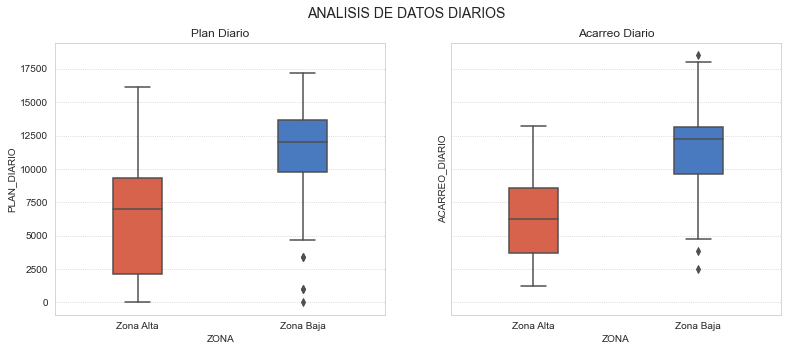

In [123]:
# Proposed themes: darkgrid, whitegrid, dark, white, and ticks
#sns.set(style='whitegrid')
sns.set_style("whitegrid", {'grid.linestyle': ':' })
fig, axes = plt.subplots(1, 2, figsize=(13,5), sharey=True)
fig.suptitle('ANALISIS DE DATOS DIARIOS', fontsize=14)
my_colors = ["#EE5435", "#3575D3"]
sns.set_palette(my_colors)
sns.boxplot( ax=axes[0], x=df2["ZONA"], y=df2["PLAN_DIARIO"], width=0.3).set_title('Plan Diario')  
sns.boxplot( ax=axes[1], x=df2["ZONA"], y=df2["ACARREO_DIARIO"], width=0.3).set_title('Acarreo Diario')


In [124]:
#Generamos Dataframe df2, Por Zona y Tipo Labor
df3 = df.groupby(['FECHA','TIPO_LABOR','ZONA'])[('PLAN_DIARIO','ACARREO_DIARIO')].sum().reset_index(['FECHA','TIPO_LABOR','ZONA'])
df3.head(3)


,FECHA,TIPO_LABOR,ZONA,PLAN_DIARIO,ACARREO_DIARIO
0,2020-01-01,Preparación,Zona Alta,0.0,533.0
1,2020-01-01,Preparación,Zona Baja,0.0,1021.0
2,2020-01-01,Tajos,Zona Alta,10000.0,7944.0


Text(0.5, 1.0, 'Acarreo Diario')

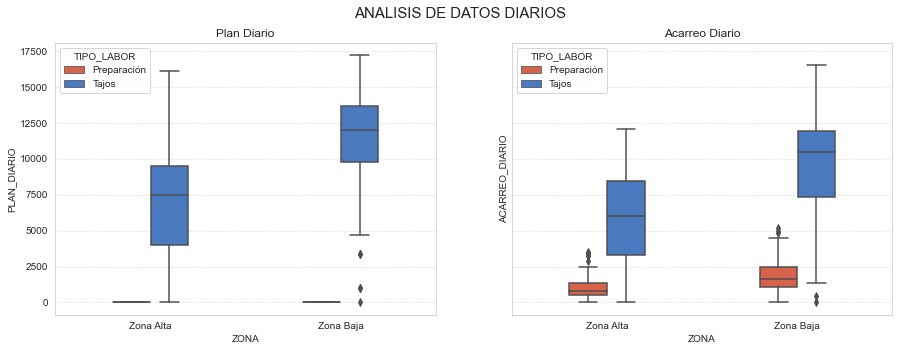

In [131]:
# Proposed themes: darkgrid, whitegrid, dark, white, and ticks
sns.set_style("whitegrid", {'grid.linestyle': ':' })
fig, axes = plt.subplots(1, 2, figsize=(15,5), sharey=True)
fig.suptitle('ANALISIS DE DATOS DIARIOS', fontsize=15)
my_colors = ["#EE5435", "#3575D3"]
sns.set_palette(my_colors)
sns.boxplot( ax=axes[0], x=df3["ZONA"], y=df3["PLAN_DIARIO"], hue=df3["TIPO_LABOR"], width=0.4).set_title('Plan Diario')  
sns.boxplot( ax=axes[1], x=df3["ZONA"], y=df3["ACARREO_DIARIO"], hue=df3["TIPO_LABOR"], width=0.4).set_title('Acarreo Diario')

<AxesSubplot:xlabel='PLAN_DIARIO', ylabel='Density'>

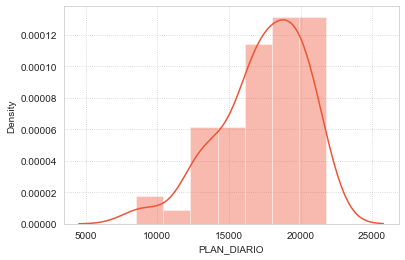

In [44]:
sns.distplot(df1["PLAN_DIARIO"])

<AxesSubplot:xlabel='ACARREO_DIARIO', ylabel='Density'>

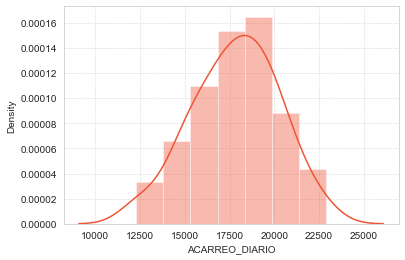

In [132]:
sns.distplot(df1["ACARREO_DIARIO"])

ANALISIS POR Quantiles Deciles

In [49]:
#Q1 = pd.deci(df1['PLAN_DIARIO']).
print(df1.quantile([0,0.25,0.5,0.75,1]))

      PLAN_DIARIO  REALIZADO_DIARIO
0.00       8500.0          12271.00
0.25      16000.0          16350.75
0.50      17900.0          17960.00
0.75      19825.0          19445.00
1.00      21800.0          22890.00


In [89]:
# Percentile values in summary, include 10% and 90%
deciles = df1['PLAN_DIARIO'].describe(percentiles=[.1, .2, .25, .3, .4, .5, .6, .7, .75, .8, .9, 1])
#deciles = df1.groupby(pd.qcut(df1.PLAN_DIARIO, 10))
#df_deciles.head(3)
deciles

count       60.000000
mean     17383.333333
std       3010.218004
min       8500.000000
10%      12980.000000
20%      14780.000000
25%      16000.000000
30%      16310.000000
40%      17120.000000
50%      17900.000000
60%      18620.000000
70%      19300.000000
75%      19825.000000
80%      20000.000000
90%      20800.000000
100%     21800.000000
max      21800.000000
Name: PLAN_DIARIO, dtype: float64

In [137]:
# Range is one indicator of spread
# Rango (R) Es una medida de variabilidad que se obtiene de la diferencia entre el máximo y mínimo valor de la variable.
# To calculate range, you subtract the smallest value from the largest value
range_Plan = df1['PLAN_DIARIO'].max() - df1['PLAN_DIARIO'].min()
print(range_Plan)

range_Acarreo = df1['ACARREO_DIARIO'].max() - df1['ACARREO_DIARIO'].min()
print(range_Acarreo)


13300.0
10619.0


In [138]:
#Rango Intercuartilico (RI)
#Se define como la diferencia entre los cuartiles tres (Q3) y uno (Q1); Cálculo: Rango Intercuartílico (RI) es el rango en el que se encuentra el 50% central de los datos.

# Calculate Interquartile Range (IQR), 75% - 25%
IQR_Plan = iqr(df1['PLAN_DIARIO'])
print(IQR_Plan)

IQR_Acarreo = iqr(df1['ACARREO_DIARIO'])
print(IQR_Acarreo)


3825.0
3094.25


In [153]:
#La desviación típica mide la dispersión de los datos respecto a la media. Se trata de la raíz cuadrada de la varianza, que en sí misma no es una medida de dispersión. Para calcular la desviación típica usamos std y var para la varianza. 

std = df1['PLAN_DIARIO'].std(ddof=1)
print ("Desviacion Estandar :", std.round(1))

var = df1['PLAN_DIARIO'].var(ddof=1)
print ("Varianza :", var.round(1))


Desviacion Estandar : 3010.2
Varianza : 9061412.4


In [158]:
#El coeficiente de variación : es una medida que sirve para comparar entre dos muestras, cuál varía más y cuál es más estable. Es una simple división, de la desviación típica sobre la media, sin embargo, SciPy nos ofrece una función ya preparada.

coef_var = ss.variation(df1['PLAN_DIARIO'])
print("Coeficiente de Variación : ", round(coef_var,3))

Coeficiente de Variación :  0.172


In [140]:
#Medidas Asimetricas : para saber si los datos estan repartidos de forma simétrica vamos a usar la función "skew" de SciPy.
#Si Ak < 0 tiene Asimetria negativa, Ak = 0 Distribucion simetrica, Ak > 0 Distribucion con Asimetria Positiva 
asimetria_Plan = skew(df1['PLAN_DIARIO'])
print("Valor de Asimetria: ", asimetria_Plan)

asimetria_Acarreo = skew(df1['ACARREO_DIARIO'])
print("Valor de Asimetria:", asimetria_Acarreo)

-0.8268646067327561
-0.21791089209262168


In [160]:

Kurtosis_Plan = kurtosis(df1['PLAN_DIARIO'])
print(Kurtosis_Plan)

Kurtosis_Acarreo = kurtosis(df1['ACARREO_DIARIO'])
print(Kurtosis_Acarreo)

0.3138927285584079
-0.3454271147090018


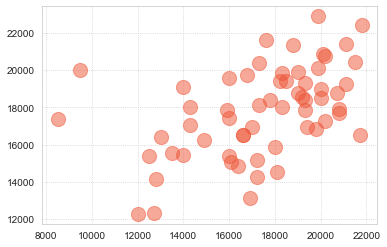

In [182]:
#Diagramas de dispersion
#colors = np.random.rand(N)
area = (30 * np.random.rand(N))**2  # 0 to 15 point radii
plt.scatter(df1['PLAN_DIARIO'], df1['ACARREO_DIARIO'], s=200, c=b, alpha=0.5)
plt.show()

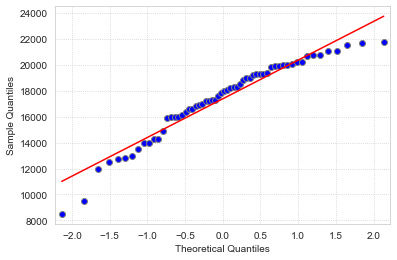

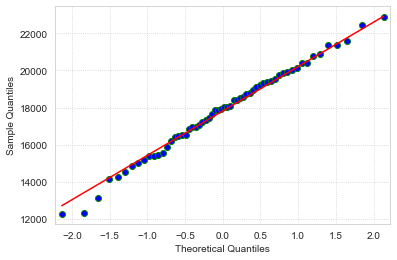

In [170]:
#Prueba borrar
from statsmodels.graphics.gofplots import qqplot
qqplot(df1['PLAN_DIARIO'], line='s' , color='grey')
qqplot(df1['ACARREO_DIARIO'], line='s',color='green')

plt.show()